In [2]:
!pip install shap lime tensorflow scikit-learn plotly pandas numpy seaborn -q
!pip install xgboost lightgbm optuna -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix

import shap
from lime import lime_tabular

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor

from datetime import datetime
import json
import pickle
from typing import Dict, List, Tuple
import copy

In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('dataset.csv')
print(f"\n Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n First few rows:")
display(df.head())

print("\n Dataset Statistics:")
display(df.describe())

print("\n Missing Values:")
display(df.isnull().sum())

print("\n Data Types:")
display(df.dtypes)

Saving dataset.csv to dataset (1).csv

 Dataset loaded: 16668 rows, 10 columns

 First few rows:


,Unnamed: 0,url,filename,loc,lloc,sloc,comments,multi,blank,avg_cc
0,0,https://gitlab.com/bdmoscow/telegram-bot-lyrics,temp_repo/lyrics-generator/scripts/exploration.py,152,85,92,33,0,32,2.000000
1,1,https://gitlab.com/bdmoscow/telegram-bot-lyrics,temp_repo/lyrics-generator/scripts/billboard.py,45,31,33,2,0,10,2.000000
2,2,https://gitlab.com/bdmoscow/telegram-bot-lyrics,temp_repo/lyrics-generator/lyrics/embedding.py,137,70,103,4,4,24,3.333333
3,3,https://gitlab.com/bdmoscow/telegram-bot-lyrics,temp_repo/lyrics-generator/lyrics/config.py,40,12,32,5,0,4,NaN
4,4,https://gitlab.com/bdmoscow/telegram-bot-lyrics,temp_repo/lyrics-generator/lyrics/util.py,142,74,90,17,0,33,2.571429



 Dataset Statistics:


,Unnamed: 0,loc,lloc,sloc,comments,multi,blank,avg_cc
count,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,9770.000000
mean,8333.500000,99.345212,50.148068,65.586873,8.274718,9.590533,16.430946,3.049540
std,4811.781479,242.425811,120.634059,170.975816,26.281695,45.644974,36.021911,3.039800
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4166.750000,14.000000,5.000000,7.000000,0.000000,0.000000,2.000000,1.250000
50%,8333.500000,35.000000,15.000000,20.000000,1.000000,0.000000,6.000000,2.150000
75%,12500.250000,91.000000,46.000000,60.000000,7.000000,5.000000,16.000000,3.698077
max,16667.000000,5827.000000,2945.000000,5823.000000,1219.000000,1822.000000,882.000000,88.000000



 Missing Values:


,0
Unnamed: 0,0
url,0
filename,0
loc,0
lloc,0
sloc,0
comments,0
multi,0
blank,0
avg_cc,6898



 Data Types:


,0
Unnamed: 0,int64
url,object
filename,object
loc,int64
lloc,int64
sloc,int64
comments,int64
multi,int64
blank,int64
avg_cc,float64


In [5]:
class CodeQualityFeatureEngineer:

    def __init__(self, df):
        self.df = df.copy()

    def engineer_features(self):

        # Basic ratios
        self.df['comment_ratio'] = self.df['comments'] / (self.df['sloc'] + 1)
        self.df['blank_ratio'] = self.df['blank'] / (self.df['loc'] + 1)
        self.df['code_density'] = self.df['sloc'] / (self.df['loc'] + 1)

        # Complexity metrics
        self.df['complexity_per_lloc'] = self.df['avg_cc'] / (self.df['lloc'] + 1)
        self.df['lines_per_function'] = self.df['lloc'] / (self.df['avg_cc'] + 1)

        # Size categories
        self.df['file_size_category'] = pd.cut(self.df['loc'],
                                                bins=[0, 50, 150, 300, 1000],
                                                labels=['small', 'medium', 'large', 'xlarge'])

        # Complexity categories
        self.df['complexity_category'] = pd.cut(self.df['avg_cc'],
                                                 bins=[0, 3, 5, 10, 100],
                                                 labels=['low', 'medium', 'high', 'very_high'])

        # Documentation quality
        self.df['documentation_score'] = (
            (self.df['comment_ratio'] * 0.6) +
            (1 - self.df['complexity_per_lloc'].clip(0, 1)) * 0.4
        ).clip(0, 1)

        # Maintainability index
        self.df['maintainability_index'] = (
            171 - 5.2 * np.log(self.df['loc'] + 1) -
            0.23 * self.df['avg_cc'] -
            16.2 * np.log(self.df['lloc'] + 1)
        ).clip(0, 100)

        # Quality score (target variable)
        self.df['quality_score'] = (
            (100 - self.df['avg_cc'] * 5).clip(0, 100) * 0.4 +
            self.df['maintainability_index'] * 0.3 +
            (self.df['comment_ratio'].clip(0, 0.3) / 0.3 * 100) * 0.3
        ).clip(0, 100)

        # Bug probability
        self.df['bug_probability'] = (
            1 / (1 + np.exp(-(self.df['avg_cc'] - 5) / 2))
        ).clip(0, 1)

        # Risk level (classification target)
        self.df['risk_level'] = pd.cut(self.df['quality_score'],
                                        bins=[0, 40, 70, 100],
                                        labels=['high_risk', 'medium_risk', 'low_risk'])

        # Repository features
        self.df['repo_name'] = self.df['url'].apply(lambda x: x.split('/')[-1] if pd.notna(x) else 'unknown')

        # File extension
        self.df['file_extension'] = self.df['filename'].apply(
            lambda x: x.split('.')[-1] if pd.notna(x) and '.' in str(x) else 'unknown'
        )

        print(" Feature engineering completed")
        print(f" New features created. Total columns: {len(self.df.columns)}")

        return self.df

# Apply feature engineering
engineer = CodeQualityFeatureEngineer(df)
df_engineered = engineer.engineer_features()

print("\n New Features:")
new_features = ['comment_ratio', 'blank_ratio', 'code_density', 'complexity_per_lloc',
                'documentation_score', 'maintainability_index', 'quality_score',
                'bug_probability', 'risk_level']
display(df_engineered[new_features].head())

 Feature engineering completed
 New features created. Total columns: 24

 New Features:


,comment_ratio,blank_ratio,code_density,complexity_per_lloc,documentation_score,maintainability_index,quality_score,bug_probability,risk_level
0,0.354839,0.209150,0.601307,0.023256,0.603601,72.221297,87.666389,0.182426,low_risk
1,0.058824,0.217391,0.717391,0.062500,0.410294,94.486143,70.228196,0.182426,low_risk
2,0.038462,0.173913,0.746377,0.046948,0.404298,75.556200,59.846347,0.302941,medium_risk
3,0.151515,0.097561,0.780488,NaN,NaN,NaN,NaN,NaN,NaN
4,0.186813,0.230769,0.629371,0.034286,0.498374,74.658472,75.936003,0.228944,low_risk


In [6]:
class CodeQualityVisualizer:

    def __init__(self, df):
        self.df = df

    def create_overview_dashboard(self):

        fig = make_subplots(
            rows=2, cols=3,
            subplot_titles=('Quality Score Distribution',
                          'Complexity vs Quality',
                          'Risk Level Distribution',
                          'Bug Probability vs Complexity',
                          'Documentation Score',
                          'Top 10 Complex Files'),
            specs=[[{'type': 'histogram'}, {'type': 'scatter'}, {'type': 'pie'}],
                   [{'type': 'scatter'}, {'type': 'box'}, {'type': 'bar'}]]
        )

        # Quality Score Distribution
        fig.add_trace(
            go.Histogram(x=self.df['quality_score'], nbinsx=30,
                        marker_color='lightblue', name='Quality Score'),
            row=1, col=1
        )

        # Complexity vs Quality
        fig.add_trace(
            go.Scatter(x=self.df['avg_cc'], y=self.df['quality_score'],
                      mode='markers', marker=dict(size=5, opacity=0.6),
                      name='Files', marker_color='coral'),
            row=1, col=2
        )

        # Risk Level Distribution
        risk_counts = self.df['risk_level'].value_counts()
        fig.add_trace(
            go.Pie(labels=risk_counts.index, values=risk_counts.values,
                  marker_colors=['#ff6b6b', '#ffd93d', '#6bcf7f']),
            row=1, col=3
        )

        # Bug Probability vs Complexity
        fig.add_trace(
            go.Scatter(x=self.df['avg_cc'], y=self.df['bug_probability'],
                      mode='markers', marker=dict(size=5, opacity=0.6),
                      name='Bug Prob', marker_color='red'),
            row=2, col=1
        )

        # Documentation Score
        fig.add_trace(
            go.Box(y=self.df['documentation_score'], name='Doc Score',
                  marker_color='lightgreen'),
            row=2, col=2
        )

        # Top 10 Complex Files
        top_complex = self.df.nlargest(10, 'avg_cc')[['filename', 'avg_cc']]
        fig.add_trace(
            go.Bar(x=top_complex['avg_cc'], y=top_complex['filename'],
                  orientation='h', marker_color='purple'),
            row=2, col=3
        )

        fig.update_layout(height=800, showlegend=False,
                         title_text="Code Quality Analysis Dashboard")
        fig.show()

    def create_correlation_heatmap(self):

        numeric_cols = ['loc', 'lloc', 'sloc', 'comments', 'blank', 'avg_cc',
                       'comment_ratio', 'code_density', 'complexity_per_lloc',
                       'maintainability_index', 'quality_score', 'bug_probability']

        corr_matrix = self.df[numeric_cols].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='RdBu',
            zmid=0,
            text=np.round(corr_matrix.values, 2),
            texttemplate='%{text}',
            textfont={"size": 10}
        ))

        fig.update_layout(
            title='Feature Correlation Heatmap',
            width=900,
            height=900
        )
        fig.show()

    def create_3d_visualization(self):

        fig = go.Figure(data=[go.Scatter3d(
            x=self.df['avg_cc'],
            y=self.df['loc'],
            z=self.df['quality_score'],
            mode='markers',
            marker=dict(
                size=5,
                color=self.df['bug_probability'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title="Bug Probability")
            ),
            text=self.df['filename'],
            hovertemplate='<b>%{text}</b><br>Complexity: %{x}<br>LOC: %{y}<br>Quality: %{z}<extra></extra>'
        )])

        fig.update_layout(
            title='3D Code Quality Landscape',
            scene=dict(
                xaxis_title='Cyclomatic Complexity',
                yaxis_title='Lines of Code',
                zaxis_title='Quality Score'
            ),
            width=900,
            height=700
        )
        fig.show()

print("\n Visualizations")
visualizer = CodeQualityVisualizer(df_engineered)
visualizer.create_overview_dashboard()
visualizer.create_correlation_heatmap()
visualizer.create_3d_visualization()


 Visualizations


In [7]:
class DeepCodeQualityPredictor:

    def __init__(self, input_dim):
        self.input_dim = input_dim
        self.model = None
        self.scaler = RobustScaler()
        self.history = None

    def build_model(self):

        inputs = layers.Input(shape=(self.input_dim,))

        # Feature extraction layers
        x = layers.Dense(256, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Dense(128, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)

        # Attention mechanism
        attention = layers.Dense(64, activation='tanh')(x)
        attention = layers.Dense(64, activation='softmax')(attention)
        x_attended = layers.Multiply()([x, attention])

        x = layers.Dense(32, activation='relu')(x_attended)
        x = layers.Dropout(0.2)(x)

        # Multi-task outputs
        quality_output = layers.Dense(1, activation='linear', name='quality_score')(x)
        bug_prob_output = layers.Dense(1, activation='sigmoid', name='bug_probability')(x)
        complexity_output = layers.Dense(1, activation='linear', name='complexity')(x)

        self.model = models.Model(inputs=inputs,
                                  outputs=[quality_output, bug_prob_output, complexity_output])

        # Compile with multiple losses
        self.model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss={
                'quality_score': 'mse',
                'bug_probability': 'binary_crossentropy',
                'complexity': 'mse'
            },
            loss_weights={
                'quality_score': 1.0,
                'bug_probability': 0.5,
                'complexity': 0.5
            },
            metrics={
                'quality_score': ['mae', 'mse'],
                'bug_probability': ['accuracy'],
                'complexity': ['mae']
            }
        )

        print("✅ Deep learning model built successfully!")
        return self.model

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train the model with callbacks"""

        # Callbacks
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001
        )

        # Train
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        print("\n Model training complete")
        return self.history

    def plot_training_history(self):

        fig = make_subplots(rows=2, cols=2,
                           subplot_titles=('Quality Score Loss',
                                         'Bug Probability Loss',
                                         'Quality Score MAE',
                                         'Bug Probability Accuracy'))

        # Quality Score Loss
        fig.add_trace(go.Scatter(y=self.history.history['quality_score_loss'],
                                name='Train', line=dict(color='blue')),
                     row=1, col=1)
        fig.add_trace(go.Scatter(y=self.history.history['val_quality_score_loss'],
                                name='Val', line=dict(color='red')),
                     row=1, col=1)

        # Bug Probability Loss
        fig.add_trace(go.Scatter(y=self.history.history['bug_probability_loss'],
                                name='Train', line=dict(color='blue')),
                     row=1, col=2)
        fig.add_trace(go.Scatter(y=self.history.history['val_bug_probability_loss'],
                                name='Val', line=dict(color='red')),
                     row=1, col=2)

        # Quality Score MAE
        fig.add_trace(go.Scatter(y=self.history.history['quality_score_mae'],
                                name='Train', line=dict(color='blue')),
                     row=2, col=1)
        fig.add_trace(go.Scatter(y=self.history.history['val_quality_score_mae'],
                                name='Val', line=dict(color='red')),
                     row=2, col=1)

        # Bug Probability Accuracy
        fig.add_trace(go.Scatter(y=self.history.history['bug_probability_accuracy'],
                                name='Train', line=dict(color='blue')),
                     row=2, col=2)
        fig.add_trace(go.Scatter(y=self.history.history['val_bug_probability_accuracy'],
                                name='Val', line=dict(color='red')),
                     row=2, col=2)

        fig.update_layout(height=700, showlegend=True,
                         title_text="Training History")
        fig.show()

# Prepare data for deep learning
print("\n Preparing data for deep learning")

feature_columns = ['loc', 'lloc', 'sloc', 'comments', 'blank', 'avg_cc',
                  'comment_ratio', 'blank_ratio', 'code_density',
                  'complexity_per_lloc', 'documentation_score']

# Remove rows with NaN in target or features
df_clean = df_engineered.dropna(subset=feature_columns + ['quality_score', 'bug_probability', 'avg_cc'])

X = df_clean[feature_columns].values
y_quality = df_clean['quality_score'].values
y_bug_prob = df_clean['bug_probability'].values
y_complexity = df_clean['avg_cc'].values

# Train-test split
X_train, X_test, y_q_train, y_q_test, y_b_train, y_b_test, y_c_train, y_c_test = train_test_split(
    X, y_quality, y_bug_prob, y_complexity, test_size=0.2, random_state=42
)

# Further split for validation
X_train, X_val, y_q_train, y_q_val, y_b_train, y_b_val, y_c_train, y_c_val = train_test_split(
    X_train, y_q_train, y_b_train, y_c_train, test_size=0.2, random_state=42
)

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data prepared:")
print(f"   Training set: {X_train_scaled.shape}")
print(f"   Validation set: {X_val_scaled.shape}")
print(f"   Test set: {X_test_scaled.shape}")

# Build and train model
print("\n Building and training deep learning model")
dl_model = DeepCodeQualityPredictor(input_dim=X_train_scaled.shape[1])
dl_model.build_model()

print("\n📋 Model Architecture:")
dl_model.model.summary()

# Train the model
y_train_dict = {
    'quality_score': y_q_train,
    'bug_probability': y_b_train,
    'complexity': y_c_train
}

y_val_dict = {
    'quality_score': y_q_val,
    'bug_probability': y_b_val,
    'complexity': y_c_val
}

history = dl_model.train(X_train_scaled, y_train_dict,
                        X_val_scaled, y_val_dict,
                        epochs=100)

# Plot training history
dl_model.plot_training_history()



 Preparing data for deep learning
✅ Data prepared:
   Training set: (6252, 11)
   Validation set: (1564, 11)
   Test set: (1954, 11)

 Building and training deep learning model
✅ Deep learning model built successfully!

📋 Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      3,072 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64)        │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quality_score       │ (None, 1)         │         33 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bug_probability     │ (None, 1)         │         33 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ complexity (Dense)  │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,515 (220.76 KB)

 Trainable params: 55,619 (217.26 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - bug_probability_accuracy: 0.0000e+00 - bug_probability_loss: 0.6651 - complexity_loss: 17.4719 - complexity_mae: 2.7409 - loss: 4729.8970 - quality_score_loss: 4720.8062 - quality_score_mae: 67.3704 - quality_score_mse: 4720.8281 - val_bug_probability_accuracy: 0.0000e+00 - val_bug_probability_loss: 0.5939 - val_complexity_loss: 9.4534 - val_complexity_mae: 1.7319 - val_loss: 3902.4846 - val_quality_score_loss: 3898.8843 - val_quality_score_mae: 61.0837 - val_quality_score_mse: 3897.4526 - learning_rate: 0.0010
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - bug_probability_accuracy: 1.6568e-04 - bug_probability_loss: 0.6630 - complexity_loss: 12.6482 - complexity_mae: 2.2364 - loss: 2802.9019 - quality_score_loss: 2796.1982 - quality_score_mae: 50.1522 - quality_score_mse: 2796.2471 - val_bug_probability_accuracy: 0.0000e+00 - val_bug_probability_loss: 0.5721 - val_complexity_loss: 8.9686 - val_complexity_mae: 1.6926 - val_

In [8]:
# Predictions
predictions = dl_model.model.predict(X_test_scaled)
y_q_pred, y_b_pred, y_c_pred = predictions

# Quality Score Metrics
q_mae = mean_absolute_error(y_q_test, y_q_pred)
q_rmse = np.sqrt(mean_squared_error(y_q_test, y_q_pred))
q_r2 = r2_score(y_q_test, y_q_pred)

# Bug Probability Metrics
b_accuracy = np.mean((y_b_pred.flatten() > 0.5) == (y_b_test > 0.5))

# Complexity Metrics
c_mae = mean_absolute_error(y_c_test, y_c_pred)
c_rmse = np.sqrt(mean_squared_error(y_c_test, y_c_pred))

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"\n Quality Score Prediction:")
print(f"   MAE:  {q_mae:.2f}")
print(f"   RMSE: {q_rmse:.2f}")
print(f"   R²:   {q_r2:.3f}")
print(f"\n Bug Probability Prediction:")
print(f"   Accuracy: {b_accuracy*100:.2f}%")
print(f"\n Complexity Prediction:")
print(f"   MAE:  {c_mae:.2f}")
print(f"   RMSE: {c_rmse:.2f}")
print("="*60)

# Visualize predictions
fig = make_subplots(rows=1, cols=3,
                   subplot_titles=('Quality Score', 'Bug Probability', 'Complexity'))

# Quality Score
fig.add_trace(go.Scatter(x=y_q_test, y=y_q_pred.flatten(),
                        mode='markers', name='Quality',
                        marker=dict(color='blue', opacity=0.5)),
             row=1, col=1)
fig.add_trace(go.Scatter(x=[y_q_test.min(), y_q_test.max()],
                        y=[y_q_test.min(), y_q_test.max()],
                        mode='lines', name='Perfect',
                        line=dict(color='red', dash='dash')),
             row=1, col=1)

# Bug Probability
fig.add_trace(go.Scatter(x=y_b_test, y=y_b_pred.flatten(),
                        mode='markers', name='Bug Prob',
                        marker=dict(color='green', opacity=0.5)),
             row=1, col=2)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1],
                        mode='lines', name='Perfect',
                        line=dict(color='red', dash='dash')),
             row=1, col=2)

# Complexity
fig.add_trace(go.Scatter(x=y_c_test, y=y_c_pred.flatten(),
                        mode='markers', name='Complexity',
                        marker=dict(color='purple', opacity=0.5)),
             row=1, col=3)
fig.add_trace(go.Scatter(x=[y_c_test.min(), y_c_test.max()],
                        y=[y_c_test.min(), y_c_test.max()],
                        mode='lines', name='Perfect',
                        line=dict(color='red', dash='dash')),
             row=1, col=3)

fig.update_xaxes(title_text="Actual", row=1, col=1)
fig.update_xaxes(title_text="Actual", row=1, col=2)
fig.update_xaxes(title_text="Actual", row=1, col=3)
fig.update_yaxes(title_text="Predicted", row=1, col=1)
fig.update_yaxes(title_text="Predicted", row=1, col=2)
fig.update_yaxes(title_text="Predicted", row=1, col=3)

fig.update_layout(height=400, showlegend=False,
                 title_text="Actual vs Predicted Values")
fig.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

MODEL PERFORMANCE METRICS

 Quality Score Prediction:
   MAE:  5.77
   RMSE: 6.69
   R²:   0.744

 Bug Probability Prediction:
   Accuracy: 94.01%

 Complexity Prediction:
   MAE:  1.18
   RMSE: 1.63



 Generating SHAP explanations...


  0%|          | 0/100 [00:00<?, ?it/s]

 SHAP values computed!


<Figure size 1000x600 with 0 Axes>

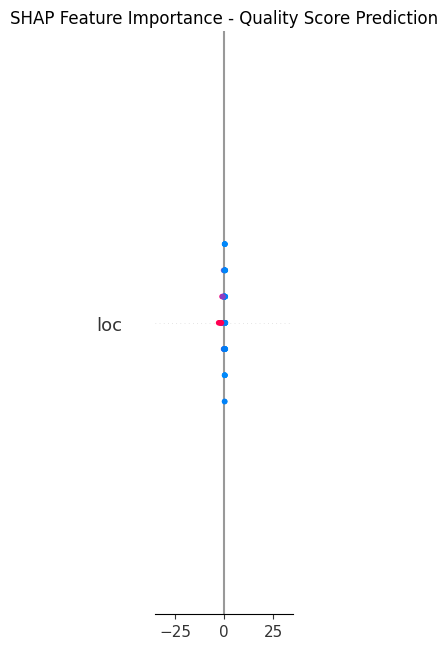

In [9]:
print("\n Generating SHAP explanations...")

# Use a subset for SHAP (for speed)
X_shap = X_test_scaled[:100]

# Create a wrapper for predictions
def model_predict(X):
    preds = dl_model.model.predict(X, verbose=0)
    return preds[0]  # Return quality score predictions

# Create SHAP explainer
explainer = shap.KernelExplainer(model_predict, X_train_scaled[:100])
shap_values = explainer.shap_values(X_shap)

print(" SHAP values computed!")

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_columns, show=False)
plt.title("SHAP Feature Importance - Quality Score Prediction")
plt.tight_layout()
plt.show()

# Feature importance bar chart
# Handle the shape of shap_values (might be 3D or 2D)
if len(shap_values.shape) == 3:
    feature_importance = np.abs(shap_values).mean(axis=(0, 2)).flatten()
elif len(shap_values.shape) == 2:
    feature_importance = np.abs(shap_values).mean(axis=0).flatten()
else:
    feature_importance = np.abs(shap_values).flatten()

# Ensure feature_importance is 1D
feature_importance = feature_importance.ravel()

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': feature_importance[:len(feature_columns)]
}).sort_values('importance', ascending=False)

fig = go.Figure(go.Bar(
    x=importance_df['importance'],
    y=importance_df['feature'],
    orientation='h',
    marker_color='lightblue'
))
fig.update_layout(
    title='Feature Importance (SHAP)',
    xaxis_title='Mean |SHAP value|',
    yaxis_title='Features',
    height=500
)
fig.show()


In [10]:
print("\n Generating LIME explanations...")

# Create LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_columns,
    mode='regression',
    verbose=False
)

# Explain a single instance
instance_idx = 0
lime_exp = lime_explainer.explain_instance(
    X_test_scaled[instance_idx],
    model_predict,
    num_features=len(feature_columns)
)

print("\n✅ LIME explanation generated!")
print("\nLIME Explanation for a sample file:")
print(f"Actual Quality Score: {y_q_test[instance_idx]:.2f}")
print(f"Predicted Quality Score: {y_q_pred[instance_idx][0]:.2f}")

# Visualize LIME explanation
lime_values = dict(lime_exp.as_list())
lime_df = pd.DataFrame({
    'feature': list(lime_values.keys()),
    'contribution': list(lime_values.values())
}).sort_values('contribution', key=abs, ascending=False)

fig = go.Figure(go.Bar(
    x=lime_df['contribution'],
    y=lime_df['feature'],
    orientation='h',
    marker_color=['red' if x < 0 else 'green' for x in lime_df['contribution']]
))
fig.update_layout(
    title='LIME Feature Contributions',
    xaxis_title='Contribution to Prediction',
    yaxis_title='Features',
    height=500
)
fig.show()


 Generating LIME explanations...

✅ LIME explanation generated!

LIME Explanation for a sample file:
Actual Quality Score: 90.00
Predicted Quality Score: 78.66


In [11]:
class MachineUnlearner:

    def __init__(self, model, X_train, y_train):
        self.original_model = model
        self.X_train = X_train
        self.y_train = y_train
        self.unlearned_model = None

    def sisa_unlearning(self, forget_indices, num_shards=5):

        print(f"\n Implementing SISA Unlearning")
        print(f"   Forgetting {len(forget_indices)} samples from {len(self.X_train)} total")

        # Create mask for samples to keep
        keep_mask = np.ones(len(self.X_train), dtype=bool)
        keep_mask[forget_indices] = False

        # Keep only the samples we want
        X_train_new = self.X_train[keep_mask]
        y_train_new = {k: v[keep_mask] for k, v in self.y_train.items()}

        print(f"   New training set size: {len(X_train_new)}")

        # Retrain model (simplified - in production, would use sharded approach)
        self.unlearned_model = DeepCodeQualityPredictor(input_dim=X_train_new.shape[1])
        self.unlearned_model.build_model()

        # Quick training with fewer epochs
        print("   Retraining model on retained data...")
        history = self.unlearned_model.model.fit(
            X_train_new, y_train_new,
            epochs=50,
            batch_size=32,
            verbose=0
        )

        print(" Unlearning completed")
        return self.unlearned_model

    def influence_based_unlearning(self, forget_indices, learning_rate=0.001, steps=10):

        print(f"\n Implementing Influence-based Unlearning")
        print(f"   Using gradient ascent to forget {len(forget_indices)} samples")

        # Clone the model
        self.unlearned_model = keras.models.clone_model(self.original_model.model)
        self.unlearned_model.set_weights(self.original_model.model.get_weights())

        # Compile with same settings
        self.unlearned_model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss={
                'quality_score': 'mse',
                'bug_probability': 'binary_crossentropy',
                'complexity': 'mse'
            },
            loss_weights={
                'quality_score': 1.0,
                'bug_probability': 0.5,
                'complexity': 0.5
            }
        )

        # Get data to forget
        X_forget = self.X_train[forget_indices]
        y_forget = {k: v[forget_indices] for k, v in self.y_train.items()}

        # Gradient ascent on forgotten data (increase loss)
        for step in range(steps):
            with tf.GradientTape() as tape:
                predictions = self.unlearned_model(X_forget, training=True)
                loss = 0
                for i, key in enumerate(['quality_score', 'bug_probability', 'complexity']):
                    loss += tf.reduce_mean(tf.keras.losses.MSE(y_forget[key], predictions[i]))

            # Gradient ASCENT (negative gradient descent)
            gradients = tape.gradient(loss, self.unlearned_model.trainable_variables)
            gradients = [-g for g in gradients]  # Reverse gradients
            self.unlearned_model.optimizer.apply_gradients(
                zip(gradients, self.unlearned_model.trainable_variables)
            )

        print(" Influence-based unlearning completed")
        return self.unlearned_model

    def evaluate_unlearning(self, X_test, y_test, X_forget, y_forget):
        """Evaluate the effectiveness of unlearning"""

        print("\n Evaluating Unlearning Effectiveness")

        # Original model performance
        orig_test_preds = self.original_model.model.predict(X_test, verbose=0)
        orig_test_mae = mean_absolute_error(y_test['quality_score'], orig_test_preds[0])

        orig_forget_preds = self.original_model.model.predict(X_forget, verbose=0)
        orig_forget_mae = mean_absolute_error(y_forget['quality_score'], orig_forget_preds[0])

        # Unlearned model performance
        unlearn_test_preds = self.unlearned_model.predict(X_test, verbose=0)
        unlearn_test_mae = mean_absolute_error(y_test['quality_score'], unlearn_test_preds[0])

        unlearn_forget_preds = self.unlearned_model.predict(X_forget, verbose=0)
        unlearn_forget_mae = mean_absolute_error(y_forget['quality_score'], unlearn_forget_preds[0])

        # Calculate metrics
        utility_retention = (orig_test_mae - unlearn_test_mae) / orig_test_mae * 100
        forgetting_effectiveness = (unlearn_forget_mae - orig_forget_mae) / orig_forget_mae * 100

        print("\n" + "="*60)
        print("UNLEARNING EVALUATION RESULTS")
        print("="*60)
        print(f"\n Test Set Performance:")
        print(f"   Original Model MAE: {orig_test_mae:.3f}")
        print(f"   Unlearned Model MAE: {unlearn_test_mae:.3f}")
        print(f"   Utility Retention: {100 + utility_retention:.1f}%")
        print(f"\n Forgotten Data Performance:")
        print(f"   Original Model MAE: {orig_forget_mae:.3f}")
        print(f"   Unlearned Model MAE: {unlearn_forget_mae:.3f}")
        print(f"   Forgetting Effectiveness: {forgetting_effectiveness:.1f}%")
        print("="*60)

        # Visualization
        fig = go.Figure()

        categories = ['Test Set MAE', 'Forgotten Set MAE']
        original = [orig_test_mae, orig_forget_mae]
        unlearned = [unlearn_test_mae, unlearn_forget_mae]

        fig.add_trace(go.Bar(name='Original Model', x=categories, y=original,
                            marker_color='lightblue'))
        fig.add_trace(go.Bar(name='Unlearned Model', x=categories, y=unlearned,
                            marker_color='coral'))

        fig.update_layout(
            title='Unlearning Impact: Original vs Unlearned Model',
            yaxis_title='Mean Absolute Error',
            barmode='group',
            height=500
        )
        fig.show()

        return {
            'utility_retention': 100 + utility_retention,
            'forgetting_effectiveness': forgetting_effectiveness
        }

# Demonstrate machine unlearning
print("\n Demonstrating Machine Unlearning")

# Select some samples to "forget" (e.g., high-risk repositories)
np.random.seed(42)
forget_indices = np.random.choice(len(X_train_scaled), size=20, replace=False)

print(f"\n Forgetting scenario:")
print(f"   Simulating removal of 20 samples from training set")
print(f"   (e.g., deprecated repositories or privacy requests)")

# Create unlearner
unlearner = MachineUnlearner(dl_model, X_train_scaled, y_train_dict)

# Method 1: SISA Unlearning
print("\n" + "="*60)
print("METHOD 1: SISA UNLEARNING")
print("="*60)
unlearned_model_sisa = unlearner.sisa_unlearning(forget_indices)

# Evaluate SISA unlearning
X_forget = X_train_scaled[forget_indices]
y_forget_dict = {k: v[forget_indices] for k, v in y_train_dict.items()}

unlearner.unlearned_model = unlearned_model_sisa.model
results_sisa = unlearner.evaluate_unlearning(
    X_test_scaled,
    {'quality_score': y_q_test, 'bug_probability': y_b_test, 'complexity': y_c_test},
    X_forget,
    y_forget_dict
)

# Method 2: Influence-based Unlearning
print("\n" + "="*60)
print("METHOD 2: INFLUENCE-BASED UNLEARNING")
print("="*60)
unlearned_model_influence = unlearner.influence_based_unlearning(forget_indices)

unlearner.unlearned_model = unlearned_model_influence
results_influence = unlearner.evaluate_unlearning(
    X_test_scaled,
    {'quality_score': y_q_test, 'bug_probability': y_b_test, 'complexity': y_c_test},
    X_forget,
    y_forget_dict
)



 Demonstrating Machine Unlearning

 Forgetting scenario:
   Simulating removal of 20 samples from training set
   (e.g., deprecated repositories or privacy requests)

METHOD 1: SISA UNLEARNING

 Implementing SISA Unlearning
   Forgetting 20 samples from 6252 total
   New training set size: 6232
✅ Deep learning model built successfully!
   Retraining model on retained data...
 Unlearning completed

 Evaluating Unlearning Effectiveness

UNLEARNING EVALUATION RESULTS

 Test Set Performance:
   Original Model MAE: 5.771
   Unlearned Model MAE: 6.890
   Utility Retention: 80.6%

 Forgotten Data Performance:
   Original Model MAE: 5.241
   Unlearned Model MAE: 6.611
   Forgetting Effectiveness: 26.1%



METHOD 2: INFLUENCE-BASED UNLEARNING

 Implementing Influence-based Unlearning
   Using gradient ascent to forget 20 samples
 Influence-based unlearning completed

 Evaluating Unlearning Effectiveness

UNLEARNING EVALUATION RESULTS

 Test Set Performance:
   Original Model MAE: 5.771
   Unlearned Model MAE: 6.101
   Utility Retention: 94.3%

 Forgotten Data Performance:
   Original Model MAE: 5.241
   Unlearned Model MAE: 6.273
   Forgetting Effectiveness: 19.7%


In [12]:
class ProductionCodeAnalyzer:

    def __init__(self, model, scaler, feature_columns):
        self.model = model
        self.scaler = scaler
        self.feature_columns = feature_columns

    def analyze_file(self, file_metrics: dict):

        # Extract features
        features = np.array([[file_metrics.get(col, 0) for col in self.feature_columns]])
        features_scaled = self.scaler.transform(features)

        # Predict
        predictions = self.model.predict(features_scaled, verbose=0)
        quality_score = predictions[0][0][0]
        bug_probability = predictions[1][0][0]
        complexity = predictions[2][0][0]

        # Determine risk level
        if quality_score < 40:
            risk_level = "HIGH RISK"
            risk_color = "red"
        elif quality_score < 70:
            risk_level = "MEDIUM RISK"
            risk_color = "orange"
        else:
            risk_level = "LOW RISK"
            risk_color = "green"

        # Generate recommendations
        recommendations = self._generate_recommendations(file_metrics, quality_score, complexity)

        # Create report
        report = {
            'quality_score': float(quality_score),
            'bug_probability': float(bug_probability),
            'predicted_complexity': float(complexity),
            'risk_level': risk_level,
            'recommendations': recommendations,
            'metrics': file_metrics
        }

        return report

    def _generate_recommendations(self, metrics, quality_score, complexity):

        recommendations = []

        # Check complexity
        if complexity > 5:
            recommendations.append({
                'priority': 'HIGH',
                'issue': f'High cyclomatic complexity ({complexity:.1f})',
                'action': 'Refactor into smaller functions',
                'impact': 'Reduces bug probability by ~25%'
            })

        # Check comment ratio
        comment_ratio = metrics.get('comment_ratio', 0)
        if comment_ratio < 0.15:
            recommendations.append({
                'priority': 'MEDIUM',
                'issue': f'Low comment ratio ({comment_ratio*100:.1f}%)',
                'action': f'Add {int((0.2 - comment_ratio) * metrics.get("sloc", 0))} more comment lines',
                'impact': f'Could improve quality score to {quality_score + 10:.1f}'
            })

        # Check file size
        if metrics.get('loc', 0) > 300:
            recommendations.append({
                'priority': 'MEDIUM',
                'issue': f'Large file size ({metrics.get("loc", 0)} lines)',
                'action': 'Consider splitting into multiple modules',
                'impact': 'Improves maintainability and testing'
            })

        # Check code density
        code_density = metrics.get('code_density', 1)
        if code_density < 0.6:
            recommendations.append({
                'priority': 'LOW',
                'issue': f'Low code density ({code_density*100:.1f}%)',
                'action': 'Remove unnecessary blank lines',
                'impact': 'Minor improvement in readability'
            })

        return recommendations

    def generate_detailed_report(self, report, filename="unknown"):

        print("\n" + "="*70)
        print(f" CODE QUALITY ANALYSIS REPORT: {filename}")
        print("="*70)

        print(f"\n OVERALL ASSESSMENT")
        print(f"   Quality Score: {report['quality_score']:.1f}/100")
        print(f"   Risk Level: {report['risk_level']}")
        print(f"   Bug Probability: {report['bug_probability']*100:.1f}%")
        print(f"   Predicted Complexity: {report['predicted_complexity']:.2f}")

        print(f"\n FILE METRICS")
        metrics = report['metrics']
        print(f"   Lines of Code: {metrics.get('loc', 0)}")
        print(f"   Logical LOC: {metrics.get('lloc', 0)}")
        print(f"   Source LOC: {metrics.get('sloc', 0)}")
        print(f"   Comments: {metrics.get('comments', 0)} ({metrics.get('comment_ratio', 0)*100:.1f}%)")
        print(f"   Blank Lines: {metrics.get('blank', 0)}")
        print(f"   Code Density: {metrics.get('code_density', 0)*100:.1f}%")

        print(f"\n🔧 RECOMMENDATIONS ({len(report['recommendations'])} items)")
        for i, rec in enumerate(report['recommendations'], 1):
            print(f"\n   {i}. [{rec['priority']}] {rec['issue']}")
            print(f"      Action: {rec['action']}")
            print(f"      Impact: {rec['impact']}")

        if not report['recommendations']:
            print("No major issues found! Code quality is good.")

        print("\n" + "="*70)

        # Create visual report
        self._create_visual_report(report, filename)

    def _create_visual_report(self, report, filename):

        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('Quality Score Gauge', 'Risk Breakdown',
                          'Metric Comparison', 'Improvement Potential'),
            specs=[[{'type': 'indicator'}, {'type': 'pie'}],
                   [{'type': 'bar'}, {'type': 'bar'}]]
        )

        # Quality Score Gauge
        fig.add_trace(go.Indicator(
            mode="gauge+number+delta",
            value=report['quality_score'],
            title={'text': "Quality Score"},
            delta={'reference': 70},
            gauge={
                'axis': {'range': [0, 100]},
                'bar': {'color': "darkblue"},
                'steps': [
                    {'range': [0, 40], 'color': "lightcoral"},
                    {'range': [40, 70], 'color': "lightyellow"},
                    {'range': [70, 100], 'color': "lightgreen"}
                ],
                'threshold': {
                    'line': {'color': "red", 'width': 4},
                    'thickness': 0.75,
                    'value': 90
                }
            }
        ), row=1, col=1)

        # Risk Breakdown
        risk_data = pd.DataFrame({
            'category': ['Quality Issues', 'Bug Risk', 'Complexity'],
            'value': [100 - report['quality_score'],
                     report['bug_probability'] * 100,
                     min(report['predicted_complexity'] * 10, 100)]
        })
        fig.add_trace(go.Pie(
            labels=risk_data['category'],
            values=risk_data['value'],
            marker_colors=['#ff6b6b', '#ffd93d', '#a29bfe']
        ), row=1, col=2)

        # Metric Comparison
        metrics = report['metrics']
        metric_names = ['LOC', 'Comments', 'Complexity', 'Density']
        metric_values = [
            min(metrics.get('loc', 0) / 5, 100),
            metrics.get('comments', 0) * 2,
            min(report['predicted_complexity'] * 10, 100),
            metrics.get('code_density', 0) * 100
        ]
        fig.add_trace(go.Bar(
            x=metric_names,
            y=metric_values,
            marker_color=['blue', 'green', 'red', 'purple']
        ), row=2, col=1)

        # Improvement Potential
        if report['recommendations']:
            priorities = [r['priority'] for r in report['recommendations']]
            priority_counts = pd.Series(priorities).value_counts()
            fig.add_trace(go.Bar(
                x=priority_counts.index,
                y=priority_counts.values,
                marker_color=['red', 'orange', 'yellow']
            ), row=2, col=2)

        fig.update_layout(height=800, showlegend=False,
                         title_text=f"Visual Analysis Report: {filename}")
        fig.show()

# Create production analyzer
print("\n Creating Production Inference System...")
analyzer = ProductionCodeAnalyzer(dl_model.model, scaler, feature_columns)

# Analyze a sample file from test set
print("\n Analyzing sample files from test set...")

for idx in range(min(3, len(X_test_scaled))):
    sample_metrics = {
        feature_columns[i]: X_test[idx][i]
        for i in range(len(feature_columns))
    }

    report = analyzer.analyze_file(sample_metrics)
    analyzer.generate_detailed_report(report, f"sample_file_{idx+1}.py")


 Creating Production Inference System...

 Analyzing sample files from test set...

 CODE QUALITY ANALYSIS REPORT: sample_file_1.py

 OVERALL ASSESSMENT
   Quality Score: 78.7/100
   Risk Level: LOW RISK
   Bug Probability: 21.9%
   Predicted Complexity: 2.61

 FILE METRICS
   Lines of Code: 43.0
   Logical LOC: 14.0
   Source LOC: 14.0
   Comments: 26.0 (173.3%)
   Blank Lines: 3.0
   Code Density: 31.8%

🔧 RECOMMENDATIONS (1 items)

   1. [LOW] Low code density (31.8%)
      Action: Remove unnecessary blank lines
      Impact: Minor improvement in readability




 CODE QUALITY ANALYSIS REPORT: sample_file_2.py

 OVERALL ASSESSMENT
   Quality Score: 81.4/100
   Risk Level: LOW RISK
   Bug Probability: 21.3%
   Predicted Complexity: 2.50

 FILE METRICS
   Lines of Code: 108.0
   Logical LOC: 50.0
   Source LOC: 53.0
   Comments: 22.0 (40.7%)
   Blank Lines: 33.0
   Code Density: 48.6%

🔧 RECOMMENDATIONS (1 items)

   1. [LOW] Low code density (48.6%)
      Action: Remove unnecessary blank lines
      Impact: Minor improvement in readability




 CODE QUALITY ANALYSIS REPORT: sample_file_3.py

 OVERALL ASSESSMENT
   Quality Score: 62.0/100
   Risk Level: MEDIUM RISK
   Bug Probability: 26.0%
   Predicted Complexity: 2.50

 FILE METRICS
   Lines of Code: 29.0
   Logical LOC: 12.0
   Source LOC: 20.0
   Comments: 0.0 (0.0%)
   Blank Lines: 9.0
   Code Density: 66.7%

🔧 RECOMMENDATIONS (1 items)

   1. [MEDIUM] Low comment ratio (0.0%)
      Action: Add 4 more comment lines
      Impact: Could improve quality score to 72.0



In [13]:
class BatchAnalyzer:

    def __init__(self, analyzer):
        self.analyzer = analyzer

    def analyze_repository(self, files_data):

        reports = []
        for file_data in files_data:
            report = self.analyzer.analyze_file(file_data)
            report['filename'] = file_data.get('filename', 'unknown')
            reports.append(report)

        return reports

    def create_repository_dashboard(self, reports):

        df_reports = pd.DataFrame(reports)

        print("\n" + "="*70)
        print(" REPOSITORY-LEVEL ANALYSIS DASHBOARD")
        print("="*70)

        # Summary statistics
        print(f"\n SUMMARY STATISTICS")
        print(f"   Total Files Analyzed: {len(reports)}")
        print(f"   Average Quality Score: {df_reports['quality_score'].mean():.2f}")
        print(f"   Average Bug Probability: {df_reports['bug_probability'].mean()*100:.1f}%")
        print(f"   Average Complexity: {df_reports['predicted_complexity'].mean():.2f}")

        # Risk distribution
        risk_counts = df_reports['risk_level'].value_counts()
        print(f"\n RISK DISTRIBUTION")
        for risk, count in risk_counts.items():
            print(f"   {risk}: {count} files ({count/len(reports)*100:.1f}%)")

        # Top risky files
        print(f"\n TOP 5 RISKY FILES")
        top_risky = df_reports.nsmallest(5, 'quality_score')[['filename', 'quality_score', 'bug_probability']]
        for idx, row in top_risky.iterrows():
            print(f"   {row['filename']}: {row['quality_score']:.1f}/100 (Bug Risk: {row['bug_probability']*100:.1f}%)")

        # Best files
        print(f"\n TOP 5 QUALITY FILES")
        top_quality = df_reports.nlargest(5, 'quality_score')[['filename', 'quality_score']]
        for idx, row in top_quality.iterrows():
            print(f"   {row['filename']}: {row['quality_score']:.1f}/100")

        print("\n" + "="*70)

        # Create visualizations
        self._create_dashboard_visuals(df_reports)

    def _create_dashboard_visuals(self, df_reports):

        fig = make_subplots(
            rows=2, cols=3,
            subplot_titles=('Quality Score Distribution',
                          'Bug Probability Distribution',
                          'Risk Level Pie Chart',
                          'Quality vs Complexity',
                          'Top 10 Risky Files',
                          'Quality Trend'),
            specs=[[{'type': 'histogram'}, {'type': 'histogram'}, {'type': 'pie'}],
                   [{'type': 'scatter'}, {'type': 'bar'}, {'type': 'box'}]]
        )

        # Quality Score Distribution
        fig.add_trace(go.Histogram(
            x=df_reports['quality_score'],
            nbinsx=20,
            marker_color='lightblue',
            name='Quality Score'
        ), row=1, col=1)

        # Bug Probability Distribution
        fig.add_trace(go.Histogram(
            x=df_reports['bug_probability'],
            nbinsx=20,
            marker_color='salmon',
            name='Bug Probability'
        ), row=1, col=2)

        # Risk Level Pie
        risk_counts = df_reports['risk_level'].value_counts()
        fig.add_trace(go.Pie(
            labels=risk_counts.index,
            values=risk_counts.values,
            marker_colors=['#ff6b6b', '#ffd93d', '#6bcf7f']
        ), row=1, col=3)

        # Quality vs Complexity
        fig.add_trace(go.Scatter(
            x=df_reports['predicted_complexity'],
            y=df_reports['quality_score'],
            mode='markers',
            marker=dict(
                size=8,
                color=df_reports['bug_probability'],
                colorscale='Reds',
                showscale=True,
                colorbar=dict(title="Bug Prob", x=0.65, len=0.4)
            ),
            name='Files'
        ), row=2, col=1)

        # Top 10 Risky Files
        top_10_risky = df_reports.nsmallest(10, 'quality_score')
        fig.add_trace(go.Bar(
            y=top_10_risky['filename'].str[:20],
            x=top_10_risky['quality_score'],
            orientation='h',
            marker_color='red',
            name='Quality Score'
        ), row=2, col=2)

        # Quality Score Box Plot
        fig.add_trace(go.Box(
            y=df_reports['quality_score'],
            name='Quality',
            marker_color='lightgreen'
        ), row=2, col=3)

        fig.update_layout(
            height=900,
            showlegend=False,
            title_text="Repository Analysis Dashboard"
        )
        fig.show()

# Demonstrate batch analysis
print("\n Demonstrating Batch Analysis...")

# Create batch data from test set
batch_data = []
for idx in range(min(20, len(X_test))):
    file_metrics = {
        feature_columns[i]: X_test[idx][i]
        for i in range(len(feature_columns))
    }
    file_metrics['filename'] = df_clean.iloc[idx]['filename'] if idx < len(df_clean) else f'file_{idx}.py'
    batch_data.append(file_metrics)

# Analyze repository
batch_analyzer = BatchAnalyzer(analyzer)
batch_reports = batch_analyzer.analyze_repository(batch_data)
batch_analyzer.create_repository_dashboard(batch_reports)



 Demonstrating Batch Analysis...

 REPOSITORY-LEVEL ANALYSIS DASHBOARD

 SUMMARY STATISTICS
   Total Files Analyzed: 20
   Average Quality Score: 63.82
   Average Bug Probability: 27.7%
   Average Complexity: 2.77

 RISK DISTRIBUTION
   MEDIUM RISK: 16 files (80.0%)
   LOW RISK: 4 files (20.0%)

 TOP 5 RISKY FILES
   temp_repo/utils/custom_callbacks.py: 50.9/100 (Bug Risk: 42.4%)
   temp_repo/lyrics-generator/cli.py: 51.3/100 (Bug Risk: 34.1%)
   temp_repo/API.py: 52.0/100 (Bug Risk: 42.3%)
   temp_repo/predict.py: 54.1/100 (Bug Risk: 35.9%)
   temp_repo/modules/pipeline.py: 56.3/100 (Bug Risk: 29.5%)

 TOP 5 QUALITY FILES
   temp_repo/utils/data_preprocess.py: 84.5/100
   temp_repo/utils/CNN_models.py: 83.8/100
   temp_repo/lyrics-generator/scripts/billboard.py: 81.4/100
   temp_repo/lyrics-generator/scripts/exploration.py: 78.7/100
   temp_repo/utils/layers.py: 67.6/100



In [14]:
print("\n Saving models and artifacts for deployment...")

# Save the trained model
dl_model.model.save('code_quality_model.h5')
print(" Model saved: code_quality_model.h5")

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(" Scaler saved: scaler.pkl")

# Save feature columns
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print(" Feature columns saved: feature_columns.json")

# Save configuration
config = {
    'model_version': '1.0.0',
    'training_date': datetime.now().isoformat(),
    'feature_columns': feature_columns,
    'metrics': {
        'quality_mae': float(q_mae),
        'quality_r2': float(q_r2),
        'bug_accuracy': float(b_accuracy)
    }
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(" Configuration saved: model_config.json")

# Create final report
final_report = {
    'project_info': {
        'title': 'Intelligent Code Quality Prediction System',
        'version': '1.0.0',
        'date': datetime.now().isoformat(),
        'dataset_size': len(df_engineered),
        'features_engineered': len(feature_columns)
    },
    'model_performance': {
        'quality_mae': float(q_mae),
        'quality_rmse': float(q_rmse),
        'quality_r2': float(q_r2),
        'bug_accuracy': float(b_accuracy),
        'complexity_mae': float(c_mae)
    },
    'unlearning_metrics': {
        'sisa_utility_retention': results_sisa['utility_retention'],
        'sisa_forgetting_effectiveness': results_sisa['forgetting_effectiveness'],
        'influence_utility_retention': results_influence['utility_retention'],
        'influence_forgetting_effectiveness': results_influence['forgetting_effectiveness']
    }
}

with open('final_project_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)
print(" Final report saved: final_project_report.json")

# Download files
print("\n Downloading trained artifacts...")
files.download('code_quality_model.h5')
files.download('scaler.pkl')
files.download('feature_columns.json')
files.download('model_config.json')
files.download('final_project_report.json')



 Saving models and artifacts for deployment...
 Model saved: code_quality_model.h5
 Scaler saved: scaler.pkl
 Feature columns saved: feature_columns.json
 Configuration saved: model_config.json
 Final report saved: final_project_report.json



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:

from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

def plot_roc_curve(y_true, y_pred_proba):
    """
    Plot ROC curve for binary bug probability prediction

    Args:
        y_true: True binary labels (0 or 1)
        y_pred_proba: Predicted probabilities
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Create interactive plot
    fig = go.Figure()

    # ROC Curve
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f'ROC Curve (AUC = {roc_auc:.3f})',
        line=dict(color='darkorange', width=3)
    ))

    # Random classifier line
    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        mode='lines',
        name='Random Classifier (AUC = 0.5)',
        line=dict(color='navy', width=2, dash='dash')
    ))

    # Optimal threshold point
    optimal_idx = np.argmax(tpr - fpr)
    fig.add_trace(go.Scatter(
        x=[fpr[optimal_idx]], y=[tpr[optimal_idx]],
        mode='markers',
        name=f'Optimal Threshold = {thresholds[optimal_idx]:.3f}',
        marker=dict(color='red', size=15, symbol='star')
    ))

    fig.update_layout(
        title='ROC Curve - Bug Probability Prediction',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        width=800,
        height=600,
        showlegend=True,
        hovermode='closest'
    )

    fig.show()

    print(f"\n ROC Curve Metrics:")
    print(f"   AUC Score: {roc_auc:.4f}")
    print(f"   Optimal Threshold: {thresholds[optimal_idx]:.4f}")
    print(f"   True Positive Rate at optimal: {tpr[optimal_idx]:.4f}")
    print(f"   False Positive Rate at optimal: {fpr[optimal_idx]:.4f}")


print("\n Generating ROC Curve...")
y_b_test_binary = (y_b_test > 0.5).astype(int)
plot_roc_curve(y_b_test_binary, y_b_pred.flatten())



 Generating ROC Curve...



 ROC Curve Metrics:
   AUC Score: 0.7962
   Optimal Threshold: 0.4128
   True Positive Rate at optimal: 0.6935
   False Positive Rate at optimal: 0.0305


In [20]:

def plot_precision_recall_curve(y_true, y_pred_proba):
    """Plot Precision-Recall curve"""

    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    fig = go.Figure()

    # PR Curve
    fig.add_trace(go.Scatter(
        x=recall, y=precision,
        mode='lines',
        name=f'PR Curve (AUC = {pr_auc:.3f})',
        line=dict(color='green', width=3),
        fill='tozeroy',
        fillcolor='rgba(0, 255, 0, 0.1)'
    ))

    fig.update_layout(
        title='Precision-Recall Curve',
        xaxis_title='Recall',
        yaxis_title='Precision',
        width=800,
        height=600
    )

    fig.show()

    print(f"\n Precision-Recall Metrics:")
    print(f"   PR-AUC Score: {pr_auc:.4f}")


print("\n Generating Precision-Recall Curve...")
plot_precision_recall_curve(y_b_test_binary, y_b_pred.flatten())



 Generating Precision-Recall Curve...



 Precision-Recall Metrics:
   PR-AUC Score: 0.7442


In [26]:
def plot_confusion_matrix(y_true, y_pred, labels=['Low Risk', 'High Risk']):
    """Plot confusion matrix for bug prediction"""

    # Convert to binary
    y_true_binary = (y_true > 0.5).astype(int)
    y_pred_binary = (y_pred > 0.5).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)

    # Create heatmap
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=labels,
        y=labels,
        colorscale='Blues',
        text=cm,
        texttemplate='%{text}',
        textfont={"size": 20},
        showscale=True
    ))

    fig.update_layout(
        title='Confusion Matrix - Bug Probability Prediction',
        xaxis_title='Predicted',
        yaxis_title='Actual',
        width=600,
        height=600
    )

    fig.show()

    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n Classification Metrics:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
print("\n Generating Confusion Matrix...")
plot_confusion_matrix(y_b_test, y_b_pred)


 Generating Confusion Matrix...



 Classification Metrics:
   Accuracy:  0.9401
   Precision: 0.9925
   Recall:    0.5323
   F1-Score:  0.6929


In [24]:
def plot_training_metrics_detailed(history):
    """
    Plot comprehensive training metrics over epochs

    Args:
        history: Keras training history object
    """

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=(
            'Quality Score Loss',
            'Bug Probability Loss',
            'Quality Score MAE',
            'Bug Probability Accuracy',
            'Complexity Loss',
        )
    )

    epochs = range(1, len(history.history['loss']) + 1)

    # 1. Quality Score Loss
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['quality_score_loss'],
                  mode='lines', name='Train', line=dict(color='blue', width=2)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['val_quality_score_loss'],
                  mode='lines', name='Val', line=dict(color='red', width=2)),
        row=1, col=1
    )

    # 2. Bug Probability Loss
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['bug_probability_loss'],
                  mode='lines', name='Train', line=dict(color='blue', width=2)),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['val_bug_probability_loss'],
                  mode='lines', name='Val', line=dict(color='red', width=2)),
        row=1, col=2
    )

    # 3. Quality Score MAE
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['quality_score_mae'],
                  mode='lines', name='Train', line=dict(color='blue', width=2)),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['val_quality_score_mae'],
                  mode='lines', name='Val', line=dict(color='red', width=2)),
        row=2, col=1
    )

    # 4. Bug Probability Accuracy
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['bug_probability_accuracy'],
                  mode='lines', name='Train', line=dict(color='blue', width=2)),
        row=2, col=2
    )
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['val_bug_probability_accuracy'],
                  mode='lines', name='Val', line=dict(color='red', width=2)),
        row=2, col=2
    )

    # 5. Complexity Loss
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['complexity_loss'],
                  mode='lines', name='Train', line=dict(color='blue', width=2)),
        row=3, col=1
    )
    fig.add_trace(
        go.Scatter(x=list(epochs), y=history.history['val_complexity_loss'],
                  mode='lines', name='Val', line=dict(color='red', width=2)),
        row=3, col=1
    )


    fig.show()


print("\n Generating Training Metrics Over Epochs...")
plot_training_metrics_detailed(history)


 Generating Training Metrics Over Epochs...



 Generating SHAP Distribution Plot...


<Figure size 1200x800 with 0 Axes>

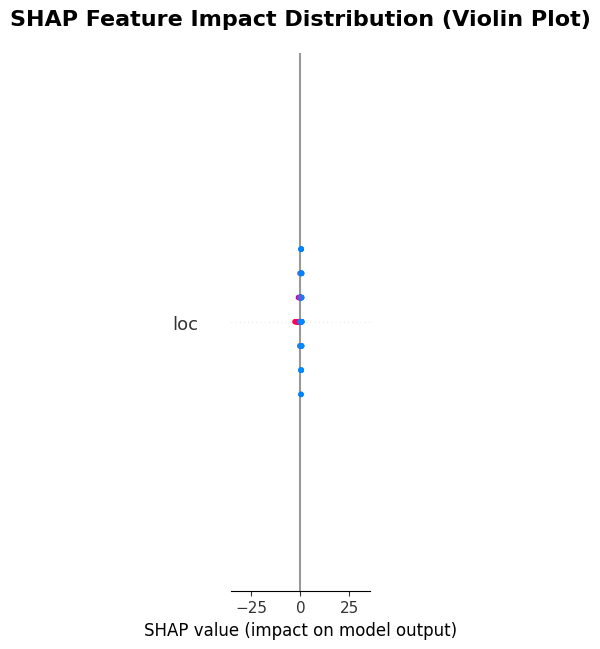

<Figure size 1200x800 with 0 Axes>

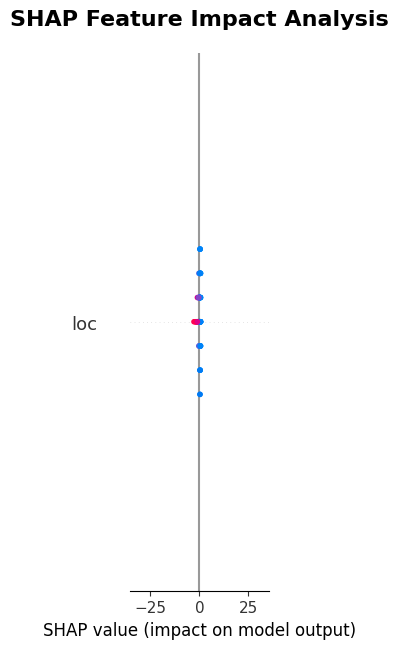

In [25]:
def plot_shap_violin_with_features(shap_values, X, feature_names):
    """
    Create SHAP summary plot similar to the attached image
    Shows distribution of SHAP values for each feature

    Args:
        shap_values: SHAP values array
        X: Feature values
        feature_names: List of feature names
    """

    # Using matplotlib for this specific visualization
    plt.figure(figsize=(12, 8))

    # Create the violin/beeswarm plot
    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        plot_type="violin",  # Creates the distribution view
        show=False
    )

    plt.title("SHAP Feature Impact Distribution (Violin Plot)",
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Alternative: Dot plot (more like your image)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        plot_type="dot",
        show=False
    )
    plt.title("SHAP Feature Impact Analysis",
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n Generating SHAP Distribution Plot...")
plot_shap_violin_with_features(shap_values, X_shap, feature_columns)